# 2. Variable signals

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import random
import natsort
import numpy as np
import pandas as pd
from textwrap import dedent

import scipy as sp
import scipy.stats as ss
from scipy.optimize import curve_fit
from scipy.signal import periodogram

from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import colormaps
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim libraries
import platosim.noise     as ns
import platosim.mocka     as mk
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.spectrum     import Spectrum
from platosim.matplotlibrc import setup_paper
setup_paper()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Define paths used throughout
vdir = os.getenv('PLATO_PROJECT_HOME') + '/inputfiles/data_varsim'
ster = '/STER/platoman/ftp'
path = os.getenv('PLATO_WORKDIR') + 'mocka'
idir = f'{path}/input'
fdir = f'{path}/figures'
sdir = f'{path}/simulations/mocka'

In [4]:
# Sampling rates [s]
dt_kepler_LC = 1765.5
dt_kepler_SC = 58.89
dt_plato_LC  = 600.0
dt_plato_MC  = 50.0
dt_plato_SC  = 25.0
dt_tess      = 2.0

# Random number generator
rng = ut.rng(12345)

---
## Synthetic SEDs for VarSim
---

In [ ]:
# Valid paramter space for PHOENIX spectra
valid_t_phoenix = np.array([*list(range(2300, 7000, 100)), 
                            *list((range(7000, 12200, 200)))])
valid_g_phoenix = np.array([*list(np.arange(0, 6, 0.5))])

# Valid parameter space for ATLAS9 spectra
valid_t_atlas9 = np.array([*list(range(3000, 1300, 250)), 
                           *list((range(13000, 50000, 1000)))])

In [ ]:
# Plot the two SED grids implemented in varsim
fig, ax = plt.subplots(1,1,figsize=(9,5))
for i in range(len(valid_g_phoenix)):
    ax.plot(valid_t_phoenix, np.ones_like(valid_t_phoenix)*valid_g_phoenix[i], 
            'o', c='royalblue', mec='w', ms=7)
    ax.plot(valid_t_atlas9,  np.ones_like(valid_t_atlas9)*valid_g_phoenix[i], 
            'd', c='deeppink', mec='w', ms=7) 
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel('log $g$')
plt.tight_layout()

---
## Passband amplitude correction
---

In [ ]:
# Code to create absolute response for TESS
#-------------------------------------------
# corr = 0.78
# plt.figure()
# plt.plot(wave_b, tran_b * corr, 'k-')
# tran_abs = tran_b * corr
# df = pd.DataFrame({'wavelength':wave_b, 'absolute':tran_abs, 'relative':tran_b})
# df.to_csv('/STER/platoman/ftp/passband_tess_new.txt', index=False)
#-------------------------------------------

In [ ]:
# Get passbands
N = 10000
wave_a, tran_a = ut.get_passband('plato', response='absolute', interpolate=True, n=N)
wave_b, tran_b = ut.get_passband('tess',  response='absolute', interpolate=True, n=N)

In [ ]:
# Load a PHOENIX star
spec = Spectrum(verbose=1)
Teff, logg, Z, alpha = spec.nearest_parameters(6700, 4.5, 0, 0, 'PhoenixHiRes')
wave_star, flux_star = spec.getPhoenixHiResFITS(Teff, logg, Z, alpha)
wave_star /= 10 # [AA -> nm]

# Find passband region and interpolate
dex_wave_min_a = ut.findNearestIndex(wave_star, wave_a[0])
dex_wave_max_a = ut.findNearestIndex(wave_star, wave_a[-1])
wave_star_a = wave_star[dex_wave_min_a:dex_wave_max_a]
flux_star_a = flux_star[dex_wave_min_a:dex_wave_max_a]
wave_equi_a, flux_equi_a = ut.rebin3(wave_a, wave_star, flux_star)

dex_wave_min_b = ut.findNearestIndex(wave_star, wave_b[0])
dex_wave_max_b = ut.findNearestIndex(wave_star, wave_b[-1])
wave_star_b = wave_star[dex_wave_min_b:dex_wave_max_b]
flux_star_b = flux_star[dex_wave_min_b:dex_wave_max_b]
wave_equi_b, flux_equi_b = ut.rebin3(wave_b, wave_star, flux_star)

# Flux within passbands
flux_tran_a = flux_equi_a * tran_a * wave_equi_a
flux_tran_b = flux_equi_b * tran_b * wave_equi_b

# Integrate to find ratio for correction
flux_a = np.trapz(flux_tran_a, wave_equi_a)
flux_b = np.trapz(flux_tran_b, wave_equi_b)

# Plot T x F
print(f'Passband correction: {flux_a/flux_b:.3f}')
plt.figure(figsize=(8,5))
plt.plot(wave_equi_a, flux_tran_a, 'k-')
plt.plot(wave_equi_b, flux_tran_b, 'r-')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Flux [arb. unit]')
plt.tight_layout();

---
## Apodization
---

In [ ]:
# Plot to investigate the NumPy sinc() function
x = np.linspace(0, 2, 1000)
plt.figure()
plt.plot(x, np.sinc(x)**2)
plt.axhline(y=0, ls=':', c='k');

In [ ]:
# Choose a sampling
nu_samp = 86400 / dt_plato_LC

# Apodization function
def AC(nu, nu_nyq):
    return np.sqrt(np.sinc(nu/nu_nyq)**(-2)), np.sinc(nu/nu_nyq)**(-2)

# Frequency parameters
nu_nyq  = nu_samp / 2
nu_range = np.linspace(0, nu_samp+nu_samp/100, 10000)

# plot apodization
fig, ax = plt.subplots(2, 1, figsize=(8,8))

for i in nu_min: ax[0].axvline(x=i, c='k', ls=':')    
ax[0].plot(nu_range, 1/AC(nu_range, nu_nyq)[0], '-',  c='orangered', label=r'$|$sinc$|$')
ax[0].plot(nu_range, 1/AC(nu_range, nu_nyq)[1], '--', c='orangered', label='sinc$^2$')
ax[0].axvline(x=nu_nyq,  c='k', label=r'$\nu_{\rm Nyq} =$ '  + f'{nu_nyq:.0f} '  + r'd$^{-1}$')
ax[0].axvline(x=nu_samp, c='k', label=r'$\nu_{\rm samp} =$ ' + f'{nu_samp:.0f} ' + r'd$^{-1}$', ls='--')
ax[0].set_xlim(nu_range[0], nu_range[-1])
ax[0].set_ylim(0, 1.05)
ax[0].legend()

for i in nu_min: ax[1].axvline(x=i, c='k', ls=':')    
ax[1].plot(nu_range, AC(nu_range, nu_nyq)[0], '-',  c='royalblue', label='$|$sinc$^{-1}|$')
ax[1].plot(nu_range, AC(nu_range, nu_nyq)[1], '--', c='royalblue', label='sinc$^{-2}$')
ax[1].axvline(x=nu_nyq,  c='k', label=r'$\nu_{\rm Nyq} =$  ' + f'{nu_nyq:.0f} '  + r'd$^{-1}$')
ax[1].axvline(x=nu_samp, c='k', label=r'$\nu_{\rm samp} =$ ' + f'{nu_samp:.0f} ' + r'd$^{-1}$', ls='--')
ax[1].set_xlim(nu_range[0], nu_range[-1])
ax[1].set_ylim(0, 50)
ax[1].legend()

# Settings
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[0].set_ylabel(r'Amplitude suppression, $(a_1 / a_0)$')
ax[1].set_ylabel(r'Amplitude correction, $(a_0 / a_1)$')
plt.tight_layout()

# Save plot
fig.savefig(f'{fdir}/apodization.png', bbox_inches='tight', dpi=300)

---
## PLATO's noise budget
---

### Test and plot clean data

In [ ]:
# Check for a single taret
star = f'{1}'.zfill(9)
idir = f'{sdir}/nsr/clean/{star}'

# Load ligth curve object
lcs = LightCurve(idir, 'multi')
N = len(lcs.files('ftr')) / 2.

# Simulation table
lc = LightCurve(lcs.files('ftr')[0])
ds = lc.star()
ds

In [ ]:
# # Check predicted NSR camera and mission level
# tdur = 3600
# noise_jitter         = ut.getJitterNoiseLimitNSR(rms=0.037, tdur=tdur)
# noise_photon_camera  = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=1, tdur=tdur)
# noise_photon_mission = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=N, tdur=tdur)
# noise_background     = ut.getBackgroundNoiseLimitNSR(ds.mag, passband='P', tdur=tdur)
# noise_camera  = noise_jitter + noise_photon_camera  + noise_background
# noise_mission = noise_jitter + noise_photon_mission + noise_background

# # print(f'Max ampl    : {dp.Amax_mag[0] * 1.037e6:.0f} ppm')
# print(f'NSR camera  : {noise_camera:.0f} ppm')
# print(f'NSR mission : {noise_mission:.0f} ppm ({int(N)} N-CAM)')

In [ ]:
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,4))

### NSR(P) at camera level

In [ ]:
ofile_bol = f'{sdir}/nsr/nsr_per_camera_BOL.ftr'
# lcs = LightCurve(f'{sdir}/nsr/clean', 'multi')
# lcs.get_nsr_per_camera(ofile_bol, suffix='ftr', quarter=1);

In [ ]:
ofile_eol = f'{sdir}/nsr/nsr_per_camera_EOL.ftr'
# lcs = LightCurve(f'{sdir}/nsr/clean', 'multi')
# lcs.get_nsr_per_camera(ofile_eol, suffix='ftr', quarter=8);

In [ ]:
# Test plot
col = 'rOA'
df = pd.read_feather(ofile_bol)
df = df.sort_values(by=[col], ascending=False)
da = df[df.SPR > 0.06]
db = df[df.SPR < 0.06]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(db, 
                                column=col, 
                                passband='P', 
                                show_ncam_noise_limits=1, 
                                show_saturation_limits=True,
                                legend=True, 
                                figsize=(10, 7))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)

# Settings
ax.set_title('Noise budget at camera level for Q1')
ax.set_xlim(6, 17)
ax.set_ylim(6, 2e4);

In [ ]:
# PLOT FOR PAPER: NOISE BUDGET AT CAMERA LEVEL FOR BOL:
#------------------------------------------------------
col = 'SPR'
df = pd.read_feather(ofile_bol)
df = df.sort_values(by=[col], ascending=False)

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='P', 
                                show_ncam_noise_limits=1, 
                                show_saturation_limits=True,
                                legend=True, 
                                grid=False, 
                                cbar_extend='max', 
                                cmap='rainbow', 
                                figsize=(8, 6))
# Settings
ax.set_title('Noise budget at camera level for BOL')
ax.set_xlim(6, 17)
ax.set_ylim(5, 2e4)
plt.legend(loc='upper left', fontsize=15);

# Save figure
fig.savefig(f'{fdir}/nsr_camera_BOL_SPR.png', bbox_inches='tight', dpi=300);

### NSR(P) at mission level

In [ ]:
ofile_bol = f'{sdir}/nsr/nsr_per_star_BOL.ftr'
# lcs = LightCurve(f'{sdir}/nsr/clean', 'multi')
# lcs.get_nsr_per_star(ofile, suffix="ftr", quarter=1);

In [ ]:
ofile_eol = f'{sdir}/nsr/nsr_per_star_EOL.ftr'
# lcs = LightCurve(f'{sdir}/nsr/clean', 'multi')
# lcs.get_nsr_per_star(ofile_eol, suffix="ftr", quarter=8);

In [ ]:
# Test plot
col = 'ncam'
df = pd.read_feather(ofile_bol)
df = df.sort_values(by=[col], ascending=False)
db = df[df.SPR > 0.06]
df = df[df.SPR < 0.06]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='P', 
                                residuals="multi", 
                                show_ncam_noise_limits=False, 
                                figsize=(10, 7))
ax.plot(db.mag, db.NSR, 'k.', alpha=0.2, zorder=-1)

# Settings
ax.set_title('Noise budget at mission level for BOL')
ax.set_xlim(7, 16.5)
ax.set_ylim(7, 6e3)
plt.legend();

In [ ]:
# PLOT FOR PAPER: NOISE BUDGET AT MISSION LEVEL FOR BOL:
#-------------------------------------------------------
col = 'ncam'
df = pd.read_feather(ofile_bol)
df = df.sort_values(by=[col], ascending=False)
db = df[df.SPR > 0.06]
df = df[df.SPR < 0.06]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='P',   
                                cmap='rainbow', 
                                figsize=(8, 6))
ax.plot(db.mag, db.NSR, 'k.', alpha=0.2, zorder=-1)

# Plot detection limits of typical amplitudes
ax.axhline(y=1728, color="orange", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\delta$ Sct \, : 1728 ppm')
ax.axhline(y=1545, color="g", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\beta$ Cep : 1545 ppm')
ax.axhline(y=1214, color="b", alpha=0.7, linestyle='--',
          zorder=5, label=r'SPB \,\,\, : 1214 ppm')
ax.axhline(y=257, color="m", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\gamma$ Dor : \, 257 ppm')

# Settings
ax.set_title('Noise budget at mission level for BOL')
ax.set_xlim(7.3, 16.7)
ax.set_ylim(8, 6e3)
plt.legend()
plt.legend();

# Save figure
fig.savefig(f'{fdir}/nsr_mission_BOL_ncam.png', bbox_inches='tight', dpi=300);

---
## $\gamma$ Doradus stars (Gang+2020)
---

### Modes in period-spacing pattern

In [5]:
# Units: freq [], ampl []
filenames_all = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020_pattern/*')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
n_off = np.zeros(N)
df = pd.DataFrame()
da = pd.DataFrame()

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1':
            
            # Here missing modes are included as 9999.
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove mising modes and store periods
            df_i = dv_i[~(dv_i.per == 9999.0)]  
            
            # Number of modes (including missing ones)
            N_mod[i] = df_i.shape[0]
            
            # First period in pattern [days]
            P0[i] = df_i.per.iloc[0]
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
            
            # Lastly fetch amplitudes by matching to all freqs
            f0 = Path(filenames_all[0])
            f1 = f0.parent / (Path(s).stem[:12] + 'very_deep_clean.dat')
            dx_i = pd.read_csv(f1, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
            dex = []
            for p in df_i.per:
                dex.append(ut.findNearestIndex(dx_i.per, p))
            dx_i = dx_i.loc[dex].reset_index()
            
            # Maximum amplitude
            A_max[i] = dx_i.amp.max()
            
            # Store amplitudes
            df = pd.concat([df, df_i]) 
            da = pd.concat([da, dx_i])
                        
#---------- Test a single star -----------
#             n_off[i] = dx_i.amp.idxmax() / dx_i.shape[0] #/ dx_i.shape[0]       
#     if i == 20:
#         break
#-----------------------------------------

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Apodization correction
P_samp = 86400 / 1800

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_gdor_gang2020.ftr')

100%|█████████████████████████████████████████████████▉| 608/609 [00:02<00:00, 206.69it/s]                                                                                                                  


In [6]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)

# Fit log-norm function to mode amplitudes
grid = 10000
A_mag  = da.amp
A_max  = A_max  * 1e3
A_mmag = da.amp * 1e3
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)
A_lognorm_mag  = ss.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2]) + 5e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 5e-5

# Fit coefficient used by varsim
print(param_mag)

(1.317739251804005, 2.180862377710758e-06, 3.1560729171583935e-05)


In [7]:
# Fetch amplitudes of input models
dv, PC, A_sim, A_PC = mk.fetch_amplitude_correction(f'{path}/simulations/mocka/GDOR/varsource')

|                                                  | 0/0 [00:00<?, ?it/s]                                                                                                                                   


AttributeError: 'DataFrame' object has no attribute 'ampl'

In [ ]:
# Histograms
panels = 6
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=60, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=100, histtype='step', density=True, ec='orange', lw=1.3)
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-', label='KDE')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=100, histtype='step', density=True, ec='red', lw=1.3)
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-', label='KDE')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

ax[4].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[4].plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax[4].set_xlim(pt.getAxesMinMax(x=A_mmag, percentage=1))
ax[4].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[4].set_ylabel('Density')
ax[4].set_yscale('log')

ax[5].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
ax[5].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
ax[5].set_xlabel(r'Passband correction, PC$_{Kepler \rightarrow \rm{PLATO}}$')
ax[5].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.08, 0.5)
    if i != 5: 
        ax[i].set_ylabel('Density')
        ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_GDOR.png', bbox_inches='tight', dpi=200)

In [ ]:
# Check range of mode periods
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(df.per, bins=100, histtype='step', density=True, ec='deeppink', lw=1.5)
P_kde = scipy.stats.gaussian_kde(df.per)
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax.plot(P_range, P_kde_hist, 'k-', label='KDE')
ax.set_xlim(0, P_range.max())
ax.set_xlabel(r'Mode period, $P$ [d]')
ax.set_ylabel('Density')
ax.set_title('Histogram of all mode periods')
plt.tight_layout()

### Test that amplitudes are correct

In [ ]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Find the CDF of the 95% of all amplitudes
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]

# Plot CDF
# plt.figure()
# plt.plot(A_lognorm_mmag, norm_cdf, '.');
# print(A_CI95, scipy.stats.lognorm.cdf(A_CI95, s=s, loc=loc, scale=scale))

# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag, A_i])

# Inspect uncertainties
bins = 1000
fig, ax = plt.subplots(1,1, figsize=(8,4))
# ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=bins, range=(0, Amax), histtype='step', density=False, lw=1.3, ec='deeppink',  label='Gang+2020')
ax.hist(A_i,    bins=bins, range=(0, Amax), histtype='step', density=False, lw=1.3, ec='royalblue', label='Test draw')
ax.axvline(x=A_CI95, c='orange', ls='--', label=r'$A_{\rm bulk}$')

ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm ({A_CI95:.3f} mmag)')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.legend()
plt.tight_layout()

In [ ]:
# TEST HOW WELL WE RECOVER MAX AMPLITUDE DISTRIBUTION OF GANG+2020
rng = ut.rng()
m = 500 #len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()

In [ ]:
# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Find the CDF of the 95% of all amplitudes
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]

# Plot max amplitude distibutions
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=False, lw=1.5, ec='deeppink',  label='Gang+2021')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=False, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_title('Validation of max amplitudes')
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout();

### Model period pattern slope

In [8]:
# Use correct stellar rotation (slope) from fit
def func(x, a, b, c, d, e):
    return  a * np.exp(-b * x) + c * np.log10(d * x) + e
P0_range  = np.linspace(dm.P0.min(), dm.P0.max(), 100)
popt, pcov = curve_fit(func, dm.P0, dm.slope)

# Fit coefficients used by varsim
print(popt)

[0.47980593 1.27007306 0.44030571 0.11200935 0.26354436]


<IPython.core.display.Javascript object>


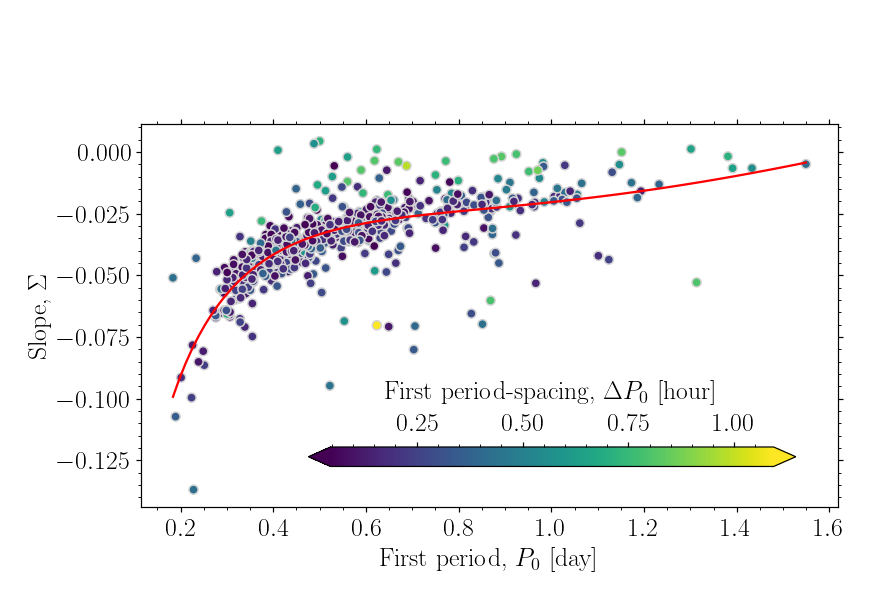

In [12]:
#----------------------------------------------
# PLOT FOR PAPER: PERIOD-SPACING PATTERN TREND:
#----------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))

im0 = ax.scatter(dm.P0, dm.slope, c=dm.dP0*24, edgecolors='lightgray', cmap='viridis')
ax.plot(P0_range, func(P0_range, *popt), 'r-')
ax.set_xlabel('First period, $P_0$ [day]')
ax.set_ylabel('Slope, $\Sigma$')
cbar = plt.colorbar(im0, orientation='horizontal', location='top', extend='both', 
                   anchor=(0.8, -7.0), shrink=0.7, aspect=25)
cbar.set_label(r"First period-spacing, $\Delta P_0$ [hour]", labelpad=10)                                    
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/gdor_dipole_mode_correlation.png', bbox_inches='tight', dpi=300)

# Save data
dm.reset_index(drop=True).to_csv('/lhome/nicholas/software/workdir/mocka/gdor_slope_vs_period.csv', index=False)

### Check simulations

In [ ]:
# Units: freq [], ampl []
filenames_all = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020_pattern/*')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
n_off = np.zeros(N)
df = pd.DataFrame()
da = pd.DataFrame()

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1':
            
            # Here missing modes are included as 9999.
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove mising modes and store periods
            df_i = dv_i[~(dv_i.per == 9999.0)]  
            
            # Number of modes (including missing ones)
            N_mod[i] = df_i.shape[0]
            
            # First period in pattern [days]
            P0[i] = df_i.per.iloc[0]
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
            
            # Lastly fetch amplitudes by matching to all freqs
            f0 = Path(filenames_all[0])
            f1 = f0.parent / (Path(s).stem[:12] + 'very_deep_clean.dat')
            dx_i = pd.read_csv(f1, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
            dex = []
            for p in df_i.per:
                dex.append(ut.findNearestIndex(dx_i.per, p))
            dx_i = dx_i.loc[dex].reset_index()
            
            # Maximum amplitude
            A_max[i] = dx_i.amp.max()
            
            # Store amplitudes
            df = pd.concat([df, df_i]) 
            da = pd.concat([da, dx_i])
                        
#---------- Test a single star --------------------------------------------
#             n_off[i] = dx_i.amp.idxmax() / dx_i.shape[0] #/ dx_i.shape[0]       
#     if i == 20:
#         break
#--------------------------------------------------------------------------

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)
P_kde     = scipy.stats.gaussian_kde(df.per)

# Fit log-norm function to mode amplitudes
grid = 10000
A_max = A_max  * 1e3
A_mag = da.amp * 1e3
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
param_mag = scipy.stats.lognorm.fit(A_mag)
A_lognorm = scipy.stats.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  
                                    scale=param_mag[2]) + 5e-5

In [ ]:
filenames = glob.glob(f'{vdir}/varsource_SPB_pedersen2021/*.dat')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
df = pd.DataFrame()
dm = pd.DataFrame()

for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    
    # Load data
    dn_i = np.loadtxt(filenames[i], comments='#', usecols=[0,2])
    dv_i = pd.DataFrame({'per':dn_i[:,0], 'ampl':dn_i[:,1]})
    
    # Calculate period spacings [days]
    n = int(dv_i.shape[0])-1
    dx_i = pd.DataFrame()
    dx_i['delta_P'] = dv_i.per.diff().dropna()
    dx_i['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
    # Remove mising modes and store periods
    df_i = dv_i[~(dv_i.per == 9999.0)]  
    
    # Number of modes (including missing ones)
    N_mod[i] = df_i.shape[0]
            
    # First period in pattern [days]
    P0[i] = df_i.per.iloc[0]
    
    # First period spacing
    dP0[i] = dx_i.delta_P.iloc[0]
            
    # Fit and find slope
    coeff = np.polyfit(dx_i.P_mean, dx_i.delta_P, 1)
    slope[i] = coeff[0]
    
    # Maximum mode amplitude
    A_max[i] = df_i.ampl.max() 
    
    # Store all modes and amplitudes
    df = pd.concat([df, df_i])
    
# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope
dm['Amax'] = -2.5*np.log10(1-A_max/1e6)
A_max  = dm.Amax * 1e3
A_mag  = -2.5*np.log10(1-df.ampl/1e6)
A_mmag = A_mag * 1e3

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_SPB_pedersen2021.ftr')

# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)
P_kde     = scipy.stats.gaussian_kde(df.per)

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Fit log-norm function to mode amplitudes
grid = 10000
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = scipy.stats.lognorm.fit(A_mag)
param_mmag = scipy.stats.lognorm.fit(A_mmag)
A_lognorm_mag  = scipy.stats.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2])  + 5e-5
A_lognorm_mmag = scipy.stats.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 5e-5

# Fit coefficient used by varsim
param_mag

In [ ]:
# LOAD SIMULATIONS
folders_parameters = natsort.natsorted(glob.glob(f'{pathv}/parameters/*'))
folders_pulsations = natsort.natsorted(glob.glob(f'{pathv}/pulsations/*'))

# Load all pulsation modes
N = len(folders_parameters)
N_modes = np.zeros(N)
PC = np.zeros(N)
df = pd.DataFrame()
for m,i,j in zip(range(N), folders_parameters, tqdm(folders_pulsations, bar_format=ut.tqdmBar())):    
    
    # Parameter file
    df_parameters = pd.read_feather(i)
    n = int(df_parameters.N_modes)
    N_modes[m] = n
    PC[m] = df_parameters.PC_kepler
    
    # Pulsation file
    df_pulsations = pd.read_feather(j)
    df_pulsations['A_PC'] = df_pulsations.ampl / PC[m]

    # Save only pulsation modes
    df = pd.concat([df, df_pulsations[:n]])
    
# A_mag = dm.ampl * 1e3
A_sim = df.ampl * 1e3
A_PC  = df.A_PC * 1e3

---
## SPB stars (Pedersen+2021)
---

In [ ]:
filenames = glob.glob(f'{vdir}/varsource_SPB_pedersen2021/*.dat')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
df = pd.DataFrame()
dm = pd.DataFrame()

for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    
    # Load data
    dn_i = np.loadtxt(filenames[i], comments='#', usecols=[0,2])
    dv_i = pd.DataFrame({'per':dn_i[:,0], 'ampl':dn_i[:,1]})
    
    # Calculate period spacings [days]
    n = int(dv_i.shape[0])-1
    dx_i = pd.DataFrame()
    dx_i['delta_P'] = dv_i.per.diff().dropna()
    dx_i['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
    # Remove mising modes and store periods
    df_i = dv_i[~(dv_i.per == 9999.0)]  
    
    # Number of modes (including missing ones)
    N_mod[i] = df_i.shape[0]
            
    # First period in pattern [days]
    P0[i] = df_i.per.iloc[0]
    
    # First period spacing
    dP0[i] = dx_i.delta_P.iloc[0]
            
    # Fit and find slope
    coeff = np.polyfit(dx_i.P_mean, dx_i.delta_P, 1)
    slope[i] = coeff[0]
    
    # Maximum mode amplitude
    A_max[i] = df_i.ampl.max() 
    
    # Store all modes and amplitudes
    df = pd.concat([df, df_i])
    
# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope
dm['Amax'] = -2.5*np.log10(1-A_max/1e6)
A_max  = dm.Amax * 1e3
A_mag  = -2.5*np.log10(1-df.ampl/1e6)
A_mmag = A_mag * 1e3

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_SPB_pedersen2021.ftr')

In [ ]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)
# Amax_kde  = scipy.stats.gaussian_kde(dm.Amax)

# Fit log-norm function to mode amplitudes
grid = 10000
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)
A_lognorm_mag  = ss.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2])  + 5e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 5e-5

# Fit coefficient used by varsim
param_mag

In [ ]:
# Fetch amplitudes of input models
df, PC, A_sim, A_PC = mk.fetch_amplitude_correction(f'{path}/simulations/analysis/SPB/varsource')

In [ ]:
# Histograms
panels = 6
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=20, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=30, histtype='step', density=True, ec='limegreen', lw=1.3)
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=30, histtype='step', density=True, ec='orange', lw=1.3)
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-', label='KDE')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=30, histtype='step', density=True, ec='red', lw=1.3)
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-', label='KDE')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

ax[4].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[4].plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax[4].set_xlim(pt.getAxesMinMax(x=A_mmag, percentage=1))
ax[4].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[4].set_ylabel('Density')
ax[4].set_yscale('log')

ax[5].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
ax[5].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
ax[5].set_xlabel(r'Passband correction, PC$_{Kepler \rightarrow \rm{PLATO}}$')
ax[5].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.08, 0.5)
    if i != 5:
        ax[i].set_ylabel('Density')
        ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_SPB.png', bbox_inches='tight', dpi=200)

In [ ]:
# Check the range of mode periods
df['per'] = 1/df.freq
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(df.per, bins=100, histtype='step', density=True, ec='deeppink', lw=1.5)
P_kde = scipy.stats.gaussian_kde(df.per)
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax.plot(P_range, P_kde_hist, 'k-', label='KDE')
ax.set_xlim(0, P_range.max())
ax.set_xlabel(r'Mode period, $P$ [d]')
ax.set_ylabel('Density')
ax.set_title('Histogram of all mode periods')
plt.tight_layout();

### Test amplitudes distribution

In [ ]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Check that the correct CDF returns correct value
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]

# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag, A_i])

# Inspect uncertainties
bins = 200
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Pedersen+2021')
ax.hist(A_i,    bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.axvline(x=A_CI95, c='orange', ls='--', label=r'$A_{\rm bulk}$')
ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm ({A_CI95:.3f} mmag)')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
# ax.set_yscale('log')
ax.legend()
plt.tight_layout();

In [ ]:
# TEST HOW WELL WE RECOVER MAX AMPLITUDE DISTRIBUTION OF GANG+2020
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot max amplitude distibutions
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Pedersen+2021')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_title('Validation of max amplitudes')
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout();

### Model period pattern slope
We do not use this as there is no clear trend!

In [ ]:
# Use correct stellar rotation (slope) from fit
def func(x, a, b): return a * x + b
P0_range  = np.linspace(dm.P0.min(), dm.P0.max(), 100)
popt, pcov = curve_fit(func, dm.P0, dm.slope)
# print(popt)

# Plot period spacing pattern
fig, ax = plt.subplots(1, 1, figsize=(7.7,7))
im0 = ax.scatter(dm.P0, dm.slope, c=dm.dP0, edgecolors='lightgray', cmap='viridis')
ax.plot(P0_range, func(P0_range, *popt), 'r-')
ax.set_xlabel('First period, $P_0$ [day]')
ax.set_ylabel('Slope, $\Sigma$')
cbar = plt.colorbar(im0, orientation='horizontal', location='top', extend='both', 
                   anchor=(0.8, -6.5), shrink=0.7, aspect=25)
cbar.set_label(r"First period-spacing, $\Delta P_0$ [day]", labelpad=10)                                    
plt.tight_layout();

---
## $\delta$ Scuti stars (Bowman+2018)
---

In [ ]:
# Units from file: freq [c/d], ampl [mmag]
filenames = glob.glob(f'{vdir}/varsource_dsct_bowman2018/*.txt')
N = len(filenames)
df = pd.DataFrame()
N_mode = np.zeros(N)
A_max  = np.zeros(N)

for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    df_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    df = pd.concat([df, df_i])
    N_mode[i] = df_i.shape[0]
    A_max[i]  = df_i.ampl.max()
    
# Remove very low frequencies
df = df[~(df.freq < 3)]

# Amplitude [mag]
df.ampl /= 1e3

# Apply apodization correction
df.ampl *= ns.apodization_correction(df.freq, dt_kepler_SC)

# Save modes (A_max [mmag])
dm = pd.DataFrame({'N':N_mode, 'A_max':A_max})

# Fetch amplitude parameters for plot
A_mmag     = df.ampl * 1e3
param      = mk.fetch_lognorm_fit(df.ampl, show=True)
param_mmag = mk.fetch_lognorm_fit(A_mmag)

In [ ]:
# GENERATE DATA USED BY VARSIM
df = df.reset_index(drop=True)
df.to_feather(f'{ster}/varsim_mocka_dsct_bowman2018.ftr')
dm = pd.DataFrame()
dm['N'] = N_mode
dm['A_max'] = A_max
dm.to_feather(f'{ster}/varsim_mocka_dsct_bowman2018_modes.ftr')

In [ ]:
# Fetch amplitudes of input models
dx, PC, A_sim, A_PC = mk.fetch_amplitude_correction(f'{path}/simulations/mocka/DSCT/varsource')

In [ ]:
# Histograms
panels = 4
grid = 10000
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=50, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde   = scipy.stats.gaussian_kde(dm.N)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
f_kde   = scipy.stats.gaussian_kde(df.freq)
f_kde_hist = f_kde(f_range)
ax[1].plot(f_range, f_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(param_mmag[0], param_mmag[1], 'k-', label='Log-norm fit')
ax[2].set_xlim(pt.getAxesMinMax(x=A_mmag, percentage=1))
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')

ax[3].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
ax[3].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
ax[3].set_xlabel(r'Passband correction, PC$_{Kepler \rightarrow \rm{PLATO}}$')
ax[3].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.09, 0.5)
    if i != 3:
        ax[i].set_ylabel('Density')
        ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_DSCT.png', bbox_inches='tight', dpi=200)

### Validate distributions

In [ ]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Compute the CDF of the amplitudes
A_range, A_param, A_lognorm = param_mmag
s, loc, scale = A_param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Check that the correct CDF returns correct value
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]
# A_CI95, scipy.stats.lognorm.cdf(A_CI95, s=s, loc=loc, scale=scale)

# Random draws using weights
N = len(A_mmag)
import random
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag.max(), A_i.max()])

# Inspect uncertainties
bins = 1000
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Bowman+2018')
ax.hist(A_i,    bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.axvline(x=A_CI95, c='orange', ls='--')
ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_xlim(-0.2, 10)
# ax.set_yscale('log')
ax.legend()
plt.tight_layout()

In [ ]:
# VALIDATE RECOVERY OF MAX AMPLITUDE DISTRIBUTION

# Random draws
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot validation
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Bowman+2018')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_title('Histogram of max amplitudes of all stars')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

---
## $\beta$ Cephei stars (Hey & Aerts 2024)
---

In [ ]:
# Extract modes: Frequencies [c/d] and Amplitudes [pp0]
df = pd.read_csv(f'{vdir}/independentSignals_detrended.csv')
rows = 36

# Remove stars with extremely high number of modes
# df = df[~(df.N_signals > 75)]

# Fetch all modes in loop
N_mode = df.N_signals
f_mode = []
A_mode = []
p_mode = []

for i in range(1,rows+1):
    freqs = df[f'f{i}'].to_numpy()
    ampls = df[f'a{i}'].to_numpy()
    phase = df[f'p{i}'].to_numpy()
        
    # Remove modes below 3 c/d
    dex = np.where(freqs > 3)[0]
    if len(dex) != 0:  
        freqs = freqs[dex].tolist()
        ampls = ampls[dex].tolist()
        phase = phase[dex].tolist()
        f_mode.append(freqs)
        A_mode.append(ampls)
        p_mode.append(phase)
    f_mode.append(freqs)
    A_mode.append(ampls)
    p_mode.append(phase)

# Save modes (A_max [ppt])
dm = pd.DataFrame({'N':N_mode, 'A_max':df.a1*1e3})

# Combine all lists into a merged list object
f_mode = np.array([x for xs in f_mode for x in xs]).flatten()
A_mode = np.array([x for xs in A_mode for x in xs]).flatten()
p_mode = np.array([x for xs in p_mode for x in xs]).flatten()
f_mode = f_mode[~np.isnan(f_mode)]
A_mode = A_mode[~np.isnan(A_mode)]
p_mode = p_mode[~np.isnan(p_mode)]
df = pd.DataFrame({'freq':f_mode, 'ampl':A_mode, 'phase':p_mode})

# Unit convertion: pp0 -> dmag
df.ampl = 2.5 * np.log(df.ampl + 1)

# Apply apodization correction
df.ampl *= ns.apodization_correction(df.freq, dt_tess)

# Fetch amplitude parameters for plot
A_mmag     = df.ampl * 1e3
param      = mk.fetch_lognorm_fit(df.ampl, show=True)
param_mmag = mk.fetch_lognorm_fit(A_mmag)

In [ ]:
# SAVE DATA FOR VARSIM
df.to_feather(f'{ster}/varsim_mocka_bcep_heyaerts2024.ftr')
dm.to_feather(f'{ster}/varsim_mocka_bcep_heyaerts2024_modes.ftr')

In [ ]:
# Fetch amplitudes of input models
filename = f'{path}/simulations/mocka/BCEP/varsource'
dx, PC, A_sim, A_PC = mk.fetch_amplitude_correction(filename, PC_name='PC_tess')

In [ ]:
# Histograms
grid, panels = 10000, 4
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=30, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde = scipy.stats.gaussian_kde(dm.N)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
f_kde = scipy.stats.gaussian_kde(df.freq)   
f_kde_hist = f_kde(f_range)
ax[1].plot(f_range, f_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(param_mmag[0], param_mmag[1], 'k-', label='Log-norm fit')
ax[2].set_xlim(pt.getAxesMinMax(x=A_mmag, percentage=1))
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')

ax[3].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
ax[3].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
ax[3].set_xlabel(r'Passband correction, PC$_{\rm{TESS} \rightarrow \rm{PLATO}}$')
ax[3].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.09, 0.5)
    if i != 3:
        ax[i].set_ylabel('Density')
        ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_BCEP.png', bbox_inches='tight', dpi=200)

### Validate simulated distributions

In [ ]:
N = len(A_mode)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mode_mmag.max(), A_i.max()])

# Inspect uncertainties
bins = 500
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(A_mode_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Hey+2024')
ax.hist(A_PC,        bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Simulation')
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

### Validate amplitude distribution

In [ ]:
# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Check that the correct CDF returns correct value
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]

# Random draws using weights
N = len(A_mode)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mode_mmag.max(), A_i.max()])

# Inspect uncertainties
bins = 500
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(A_mode_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Hey+2024')
ax.hist(A_i,         bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.axvline(x=A_CI95, c='orange', ls='--')
ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
# ax.set_yscale('log')
ax.legend()
plt.tight_layout()

### Validate max amplitude distribution

In [ ]:
# Random draws
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot validation
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=False, lw=1.5, ec='royalblue', label='Simulated')
h = ax.hist(A_max, bins=100, histtype='step', density=False, lw=1.5, ec='deeppink',  label='Hey\&Aerts2024')
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [ppt]')
ax.set_ylabel('Number count')
ax.set_title('Histogram of max amplitudes of all stars')
ax.legend()
plt.tight_layout();

---
## RR Lyrae stars (Emese)
---

In [ ]:
# Prepare data 
filenames = glob.glob(f'{vdir}/varsource_rrly_bodi2023/*.fou')
N = len(filenames)
df = pd.DataFrame()
N_mode = np.zeros(N)
A_max  = np.zeros(N)

# Fetch all modes in loop
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    df_i = pd.read_csv(f, sep='  ', names=['freq', 'ampl', 'phase'])              
    df = pd.concat([df, df_i])
    N_mode[i] = df_i.shape[0]
    A_max[i]  = df_i.ampl.max()

# Convert units
A_mag  = df.ampl
A_mmag = A_mag * 1e3

# Compute KDEs
N_kde = scipy.stats.gaussian_kde(N_mode)
f_kde = scipy.stats.gaussian_kde(df.freq)

In [ ]:
# Log-norm fit to amplitudes
grid = 1000

A_range      = np.linspace(0, A_mag.max(),  grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)

param      = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)

A_lognorm      = ss.lognorm.pdf(A_range,      param[0],      loc=param[1],      scale=param[2])      + 1e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 1e-5

param

In [ ]:
# Histograms
grid, panels = 10000, 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=29, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=70, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(0, A_mmag.max())

# ax[3].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
# ax[3].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
# ax[3].set_xlabel(r'Passband correction, PC$_{Kepler \rightarrow \rm{PLATO}}$')
# ax[3].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.09, 0.5)
    if i != 3:
        ax[i].set_ylabel('Density')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_RRLYR.png', bbox_inches='tight', dpi=200)

In [ ]:
# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Check that the correct CDF returns correct value
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]
print(A_CI95)
# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag.max(), A_i.max()])

# Inspect uncertainties
bins = 500
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(A_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Atila Bodi')
ax.hist(A_i,    bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.axvline(x=A_CI95, c='orange', ls='--')
ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

---
## Cepheid stars (Emese)
---

In [ ]:
# Prepare data 
filenames = glob.glob(f'{vdir}/varsource_ceph_bodi2023/*.fou')
N = len(filenames)
df = pd.DataFrame()
N_mode = np.zeros(N)
A_max  = np.zeros(N)

# Fetch all modes in loop
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    df_i = pd.read_csv(f, sep='  ', names=['freq', 'ampl', 'phase'])              
    df = pd.concat([df, df_i])
    N_mode[i] = df_i.shape[0]
    A_max[i]  = df_i.ampl.max()

# Convert units
A_mag  = df.ampl
A_mmag = A_mag * 1e3

# Compute KDEs
N_kde = scipy.stats.gaussian_kde(N_mode)
f_kde = scipy.stats.gaussian_kde(df.freq)

In [ ]:
# Log-norm fit to amplitudes
grid = 1000

A_range      = np.linspace(0, A_mag.max(),  grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)

param      = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)

A_lognorm      = ss.lognorm.pdf(A_range,      param[0],      loc=param[1],      scale=param[2])      + 1e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 1e-5

param

In [ ]:
# Histograms
grid, panels = 10000, 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=24, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=70, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mmag, bins=100, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(0, A_mmag.max())

# ax[3].hist(PC, bins=100, histtype='step', density=True, ec='m', lw=1.3)
# ax[3].set_xlim(pt.getAxesMinMax(x=PC, percentage=1))
# ax[3].set_xlabel(r'Passband correction, PC$_{Kepler \rightarrow \rm{PLATO}}$')
# ax[3].set_ylabel('Count')

for i in range(panels): 
    ax[i].get_yaxis().set_label_coords(-0.09, 0.5)
    if i != 3:
        ax[i].set_ylabel('Density')
plt.tight_layout(pad=0.5);

# Save figure
fig.savefig(f'{fdir}/varsource_hist_CEPH.png', bbox_inches='tight', dpi=200)

In [ ]:
# Compute the CDF of the amplitudes
s, loc, scale = param_mmag
norm_cdf = scipy.stats.lognorm.cdf(A_lognorm_mmag, s=s, loc=loc, scale=scale)

# Check that the correct CDF returns correct value
A_CI95 = A_lognorm_mmag[ut.findNearestIndex(norm_cdf, 0.95)]

# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag.max(), A_i.max()])

# Inspect uncertainties
bins = 500
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(A_mmag, bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Hey+2024')
ax.hist(A_i,    bins=bins, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.axvline(x=A_CI95, c='orange', ls='--')
ax.set_title(f'Bulk of amplitudes: {(10**(0.4*A_CI95*1e-3)-1)*1e6:.1f} ppm')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

---
## Compact pulsators (Murat)
---

In [8]:
def get_pulsations(file, star_with_mma_ampl=None):
    # Coloumns: freq [mhHz], ampl [ppt]
    df = pd.read_csv(file)
    filename = Path(file).name
    if star_with_mma_ampl is not None:
        if filename in star_with_mma_ampl:
            df['ampl']  = ut.mmag2ppt(df.ampl)
    return df, filename

In [9]:
def plot_nsr_lines(fval, da=0.07):
    ncam06 = [ 0.2, 0.6, 4.0]  # P = {12, 14, 16} mag
    ncam24 = [0.08, 0.3, 3.0]  # P = {12, 14, 16} mag
    ax.axhline(y=ncam06[0], c='royalblue', ls=':')
    ax.axhline(y=ncam06[1], c='royalblue', ls='--')
    ax.axhline(y=ncam06[2], c='royalblue', ls='-.')
    ax.axhline(y=ncam24[0], c='tomato', ls=':')
    ax.axhline(y=ncam24[1], c='tomato', ls='--')
    ax.axhline(y=ncam24[2], c='tomato', ls='-.')
    ax.text(fval, ncam06[0]+ncam06[0]*da, r'$n_{\rm CAM}=6$,  $P=12$', fontsize=13)
    ax.text(fval, ncam06[1]+ncam06[1]*da, r'$n_{\rm CAM}=6$,  $P=14$', fontsize=13)
    ax.text(fval, ncam06[2]+ncam06[2]*da, r'$n_{\rm CAM}=6$,  $P=16$', fontsize=13)
    ax.text(fval, ncam24[0]+ncam24[0]*da, r'$n_{\rm CAM}=24$, $P=12$', fontsize=13)
    ax.text(fval, ncam24[1]+ncam24[1]*da, r'$n_{\rm CAM}=24$, $P=14$', fontsize=13)
    ax.text(fval, ncam24[2]+ncam24[2]*da, r'$n_{\rm CAM}=24$, $P=16$', fontsize=13)

### Hot subdwarfs (sdBV)

In [17]:
# Download data from FTP server (orginal file "FTlist.ods")
folder = 'varsource_sdBV_uzundag2024'
ut.downloadFromFTP(f'{folder}.zip', vdir)

# Load in original dataset from file "FTlist.ods"
files = sorted(glob.glob(f'{vdir}/{folder}/*'))
files

['/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC203948264.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC212707862.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC215776487.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC217280630.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC218366972.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC218717602.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_EPIC220641886.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_sdBV_uzundag2024/pulsations_KIC02437937.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsi

<IPython.core.display.Javascript object>


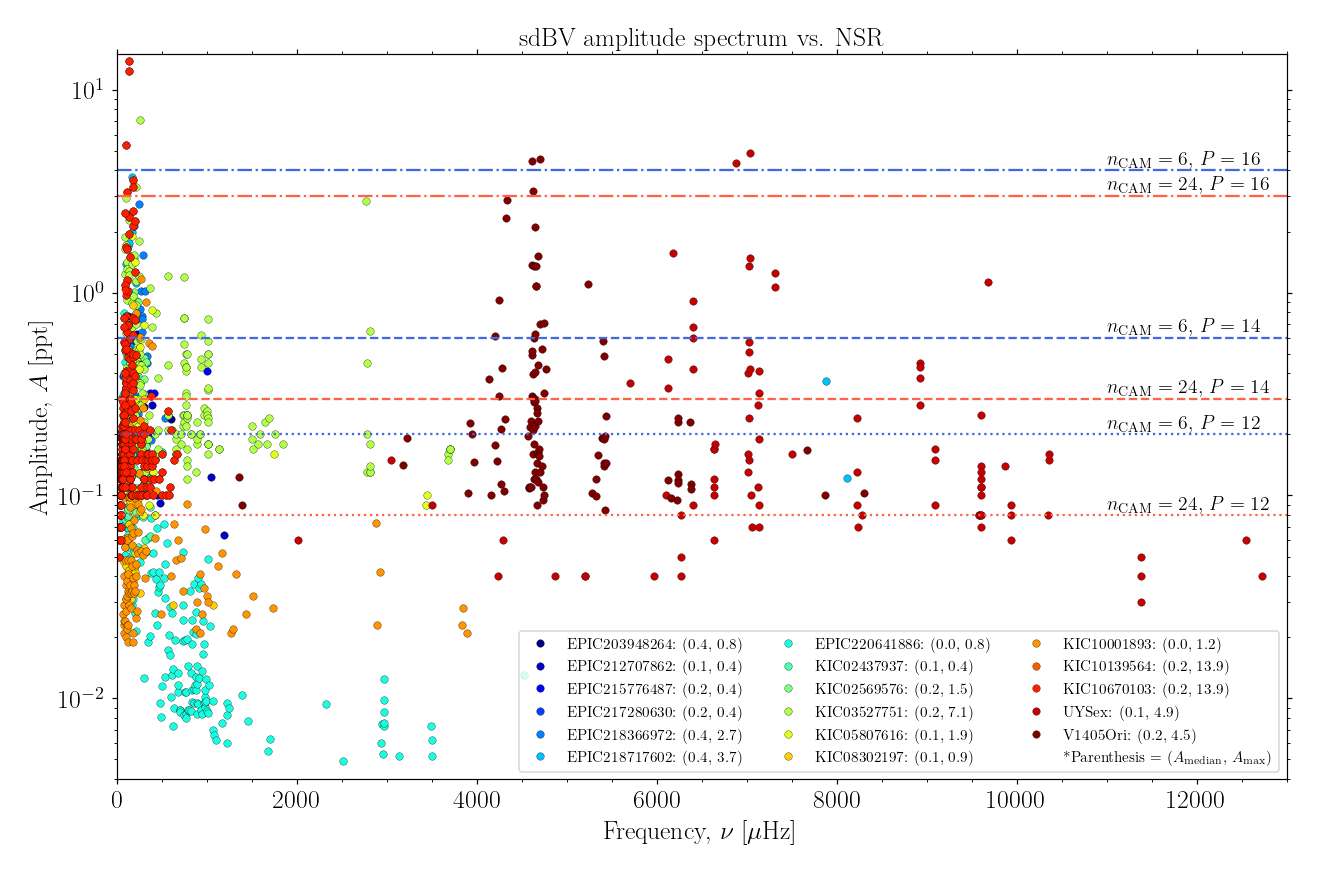

In [62]:
# Check all amplitude against NSR at BOL and mission level
n = len(files)
nvals = np.arange(n)
normalize = mcolors.Normalize(vmin=nvals.min(), vmax=nvals.max())
colormap = colormaps['jet']

# Plotting
fig, ax = plt.subplots(1,1, figsize=(12.1,8))
for i in range(n):
    df, filename = get_pulsations(files[i])
    plt.plot(df.freq, df.ampl, 'o', ms=5, color=colormap(normalize(i)), mec='k', mew=0.2,
             label=f'{filename[11:-4]}: ({df.ampl.median():.1f}, {df.ampl.max():.1f})')
ax.plot(1,1, 'wo', label=r'*Parenthesis = ($A_{\rm median}$, $A_{\rm max}$)')
plot_nsr_lines(fval=11000)

# Settings
plt.title('sdBV amplitude spectrum vs. NSR')
ax.set_ylabel(r'Amplitude, $A$ [ppt]')
ax.set_xlabel(r'Frequency, $\nu$ [$\mu$Hz]')
ax.legend(ncols=3, fontsize=10, loc='lower right')
ax.set_xlim(0, 13000)
ax.set_ylim(0.004, 15)
ax.set_yscale('log')
plt.tight_layout()

# Save plot
fig.savefig(f'{fdir}/varsource_puls_SDBV.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


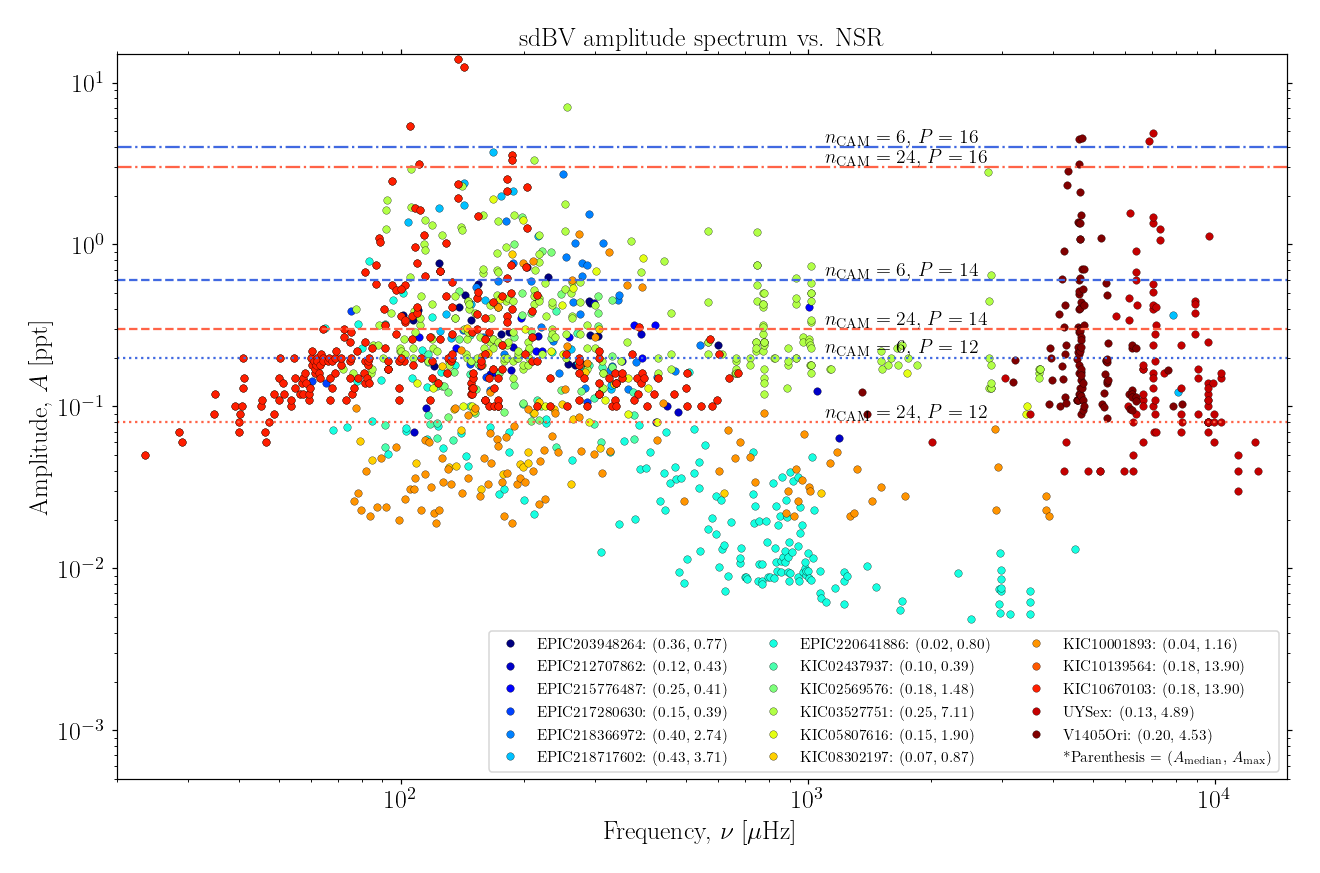

In [64]:
# Use log-x to zoom-in on majority of modes
n = len(files)
nvals = np.arange(n)
normalize = mcolors.Normalize(vmin=nvals.min(), vmax=nvals.max())
colormap = colormaps['jet']

# Plotting
fig, ax = plt.subplots(1,1, figsize=(12.1,8))
for i in range(n):
    df, filename = get_pulsations(files[i])
    plt.plot(df.freq, df.ampl, 'o', ms=5, color=colormap(normalize(i)), mec='k', mew=0.2,
             label=f'{filename[11:-4]}: ({df.ampl.median():.2f}, {df.ampl.max():.2f})')
ax.plot(1,1, 'wo', label=r'*Parenthesis = ($A_{\rm median}$, $A_{\rm max}$)')
plot_nsr_lines(fval=1.1e3)

# Settings
plt.title('sdBV amplitude spectrum vs. NSR')
ax.set_ylabel(r'Amplitude, $A$ [ppt]')
ax.set_xlabel(r'Frequency, $\nu$ [$\mu$Hz]')
ax.legend(ncols=3, fontsize=10, loc='lower right')
ax.set_xlim(2e1, 15e3)
ax.set_ylim(5e-4, 15e0)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()

# Save plot
fig.savefig(f'{fdir}/varsource_puls_SDBV_logx.png', bbox_inches='tight', dpi=200)

In [13]:
# GENERATE VARIABLE TEMPLATES
for i in tqdm(range(len(files)), bar_format=ut.tqdmBar()):
    
    # Coloumns: freq [mhHz], ampl [ppt]
    df = pd.read_csv(files[i])
    filename = Path(files[i]).name

    # Convert columns: freq [c/d], ampl [mag] 
    df['freq']  = ut.muhz2cpd(df.freq)
    df['ampl']  = ut.ppt2mmag(df.ampl) / 1e3
    df['phase'] = rng.uniform(0, 2*np.pi, df.shape[0])

    # Generate light curve from pulsations
    dv = pd.DataFrame()
    dv['time'] = np.arange(0, 2*ut.year(), 25)
    dv['dmag'] = ns.timeSeriesFromFourier(dv.time/86400, df.freq, df.ampl, df.phase, power=1)

    # Write output file
    varsource_folder = Path(f'{sdir}/SDBV/varsource')
    varsource_folder.mkdir(parents=True, exist_ok=True)
    ofile = f'{varsource_folder}/varsource_SDBV_{filename[11:]}' 
    data = np.transpose([dv.time, dv.dmag])
    np.savetxt(ofile, data, fmt=['%.1f', '%.8f'])

100%|██████████████████████████████████████████████████| 17/17 [01:16<00:00,  4.48s/it]                                                                                                                     


<IPython.core.display.Javascript object>


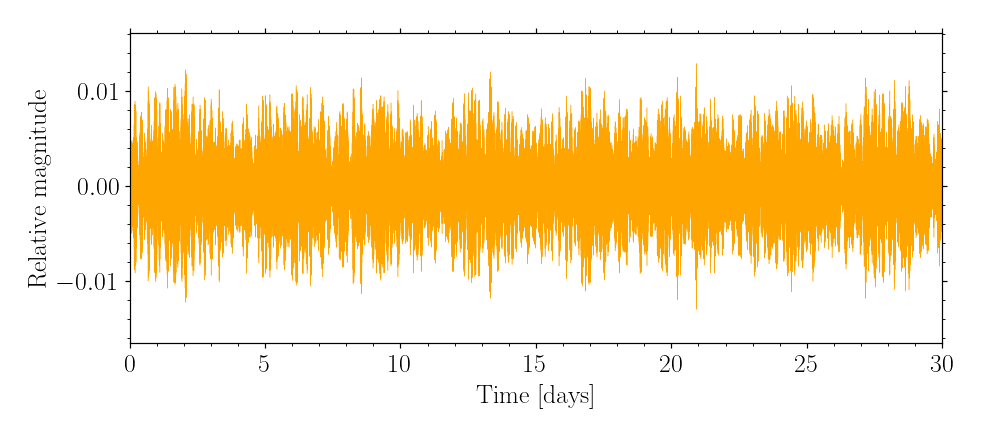

In [20]:
# Plot the last light curve generated
fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.dmag, '-', c='orange', lw=0.3)
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative magnitude')
ax.set_xlim(0, 30)
plt.tight_layout();

### White Dwarfs (WD)

In [5]:
# Download data from FTP server (orginal file "FTlist.ods")
# Note: KIC/EPIC targets are from: http://k2wd.org/ZZ/ZZ.html
folder = 'varsource_WD_uzundag2024'
ut.downloadFromFTP(f'{folder}.zip', vdir)

# Load in original dataset from file "FTlist.ods"
files = sorted(glob.glob(f'{vdir}/{folder}/*'))
files

['/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC201719578.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC201802933.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC210397465.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC211926430.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC220204626.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC220258806.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_EPIC229227292.txt',
 '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim/varsource_WD_uzundag2024/pulsations_DAV_KIC04357037.txt',
 '/lhome/nicholas/software/PlatoSim3/input

In [6]:
# Stars with ampl [mma]
star_with_mma_ampl = [
    'pulsations_DAV_TIC033986466.txt',
    'pulsations_DAV_TIC101014997.txt',
    'pulsations_DAV_TIC164772507.txt',
    'pulsations_DBV_TIC257459955.txt',
    'pulsations_DOV_TIC035062562.txt',
]

<IPython.core.display.Javascript object>


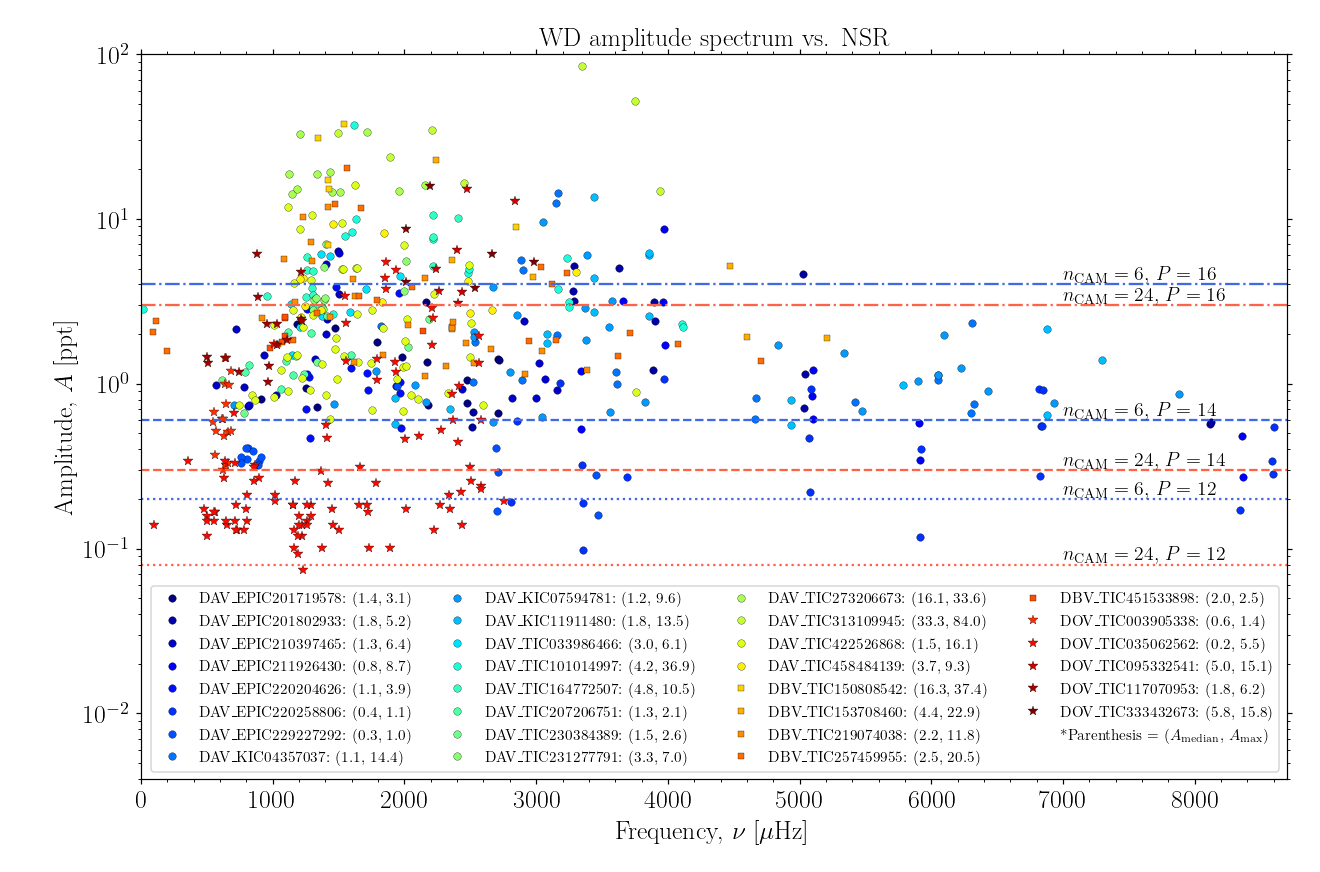

In [10]:
# Check all amplitude against NSR at BOL and mission level
n = len(files)
nvals = np.arange(n)
normalize = mcolors.Normalize(vmin=nvals.min(), vmax=nvals.max())
colormap = colormaps['jet']

# Plotting
fig, ax = plt.subplots(1,1, figsize=(12.1,8))
for i in range(n):
    df, filename = get_pulsations(files[i], star_with_mma_ampl)
    name = filename[11:-4]
    star = name[:3]
    if star == 'DAV': 
        marker = 'o'
        ms = 5
    elif star == 'DBV': 
        marker = 's'
        ms = 4
    elif star == 'DOV':
        marker = '*'
        ms = 7
    plt.plot(df.freq, df.ampl, marker, ms=ms, color=colormap(normalize(i)), mec='k', mew=0.2,
             label=f'{name}: ({df.ampl.median():.1f}, {df.ampl.max():.1f})')
ax.plot(1,1, 'wo', label=r'*Parenthesis = ($A_{\rm median}$, $A_{\rm max}$)')
plot_nsr_lines(fval=7000)

# Settings
plt.title('WD amplitude spectrum vs. NSR')
ax.set_ylabel(r'Amplitude, $A$ [ppt]')
ax.set_xlabel(r'Frequency, $\nu$ [$\mu$Hz]')
ax.legend(ncols=4, fontsize=10, loc='lower right')
ax.set_xlim(0, 8700)
ax.set_ylim(0.004, 100)
ax.set_yscale('log')
plt.tight_layout()

# Save plot
fig.savefig(f'{fdir}/varsource_puls_WD.png', bbox_inches='tight', dpi=200)

In [ ]:
# GENERATE VARIABLE TEMPLATES
for i in tqdm(range(len(files)), bar_format=ut.tqdmBar()):
    
    # Load pulsation modes: freq [mhHz], ampl [ppt, mma]
    df = pd.read_csv(files[i])
    
    # Convert columns: freq [muHz -> c/d], ampl [mmag/ppt -> mag] 
    df['freq']  = df.freq / 1e6 * 86400
    filename = Path(files[i]).name
    if filename in star_with_mma_ampl:
        df['ampl']  = df.ampl / 1e3
    else:
        df['ampl']  = ut.ppt2mmag(df.ampl) / 1e3
    df['phase'] = rng.uniform(0, 2*np.pi, df.shape[0])
    
    # Generate light curve from pulsations
    dv = pd.DataFrame()
    dv['time'] = np.arange(0, 2*ut.year(), 25)
    dv['dmag'] = ns.timeSeriesFromFourier(dv.time/86400, df.freq, df.ampl, df.phase, power=1)

    # Write output file
    varsource_folder = Path(f'{path}/varsource/WD')
    varsource_folder.mkdir(parents=True, exist_ok=True)
    ofile = f'{varsource_folder}/varsource_WD_{filename[11:]}' 
    data = np.transpose([dv.time, dv.dmag])
    np.savetxt(ofile, data, fmt=['%.1f', '%.8f'])

In [ ]:
# Plot the last light curve generated
fig, ax = plt.subplots(1, 1, figsize=(9,4))
ax.plot(dv.time/86400, dv.dmag, '-', c='orange', lw=0.3)
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative magnitude')
ax.set_xlim(0, 30)
plt.tight_layout();

### SLURM job scripts

In [ ]:
def slurm_script_sims(pulsator, batch, files, odir):
    
    # Create ouput folder
    odir = Path(odir)
    odir.mkdir(parents=True, exist_ok=True)
    
    # First string of run script
    run_script = "# Script to submit all SLURM sims jobs\n"
    
    for file in files:
        oname = Path(file).stem[11:]

        if batch in ['affogato', 'doppio']:
            noise = 'expected'
        elif batch == 'cortado':
            noise = 'required'
        else:
            errorcode('error', 'Incorrect "noise" argument')

        script = f"""
        #!/bin/bash -l

        #SBATCH -A lp_platosimulator
        #SBATCH --mail-user=nicholas.jannsen@kuleuven.be
        #SBATCH --mail-type=END
        #SBATCH --mail-type=FAIL
        #SBATCH -o output_sim_{oname}
        #SBATCH -M genius
        #SBATCH -p batch
        #SBATCH --nodes=1
        #SBATCH --ntasks-per-node=36
        #SBATCH -t 30:00:00

        cd $SLURM_SUBMIT_DIR
        module purge
        module restore platosim_genius

        # User defined parameters
        STARID=$(printf "%09d" $id)
        PROJECT=mocka
        SIMDIR={pulsator}
        OBJECT={oname}
        BATCH={batch}
        NOISE={noise}
        """ + """
        # Export paths
        export OMP_NUM_THREADS=1
        export PLATO_WORKDIR=$VSC_DATA/workdir
        export PLATO_PROJECT_HOME=$VSC_DATA/PlatoSim3
        export PYTHONPATH=$PLATO:$PLATO_PROJECT_HOME/python
        export PATH=$VSC_DATA/miniconda3/bin:$PATH

        # Export user parameters
        export TEMDIR=$VSC_SCRATCH_NODE
        export OUTDIR=$VSC_SCRATCH/platosim/$PROJECT/$SIMDIR/output_${BATCH}/$OBJECT/$STARID
        export VARFILE=$VSC_SCRATCH/platosim/$PROJECT/$SIMDIR/varsource/varsource_${SIMDIR}_${OBJECT}.txt
        export PLATONIUM=$PLATO_PROJECT_HOME/python/platosim/platonium/platonium.py

        # Activate environment
        source activate platonium

        # Run PLATOnium
        for quarter in 1 2 3 4 5 6 7 8
        do
            python $PLATONIUM $id $group $camera $quarter --project ${PROJECT}_${BATCH} --sample $SIMDIR -o $TEMDIR -s $OUTDIR --varfile $VARFILE --performance $NOISE --seed 12345 --detrend poly --clip -v 0 -w
        done
        """
        
        # Save files to output folder
        ofile = f'{odir}/sims_{oname}.slurm'
        with open(ofile, "w") as out_file:
            out_file.write(dedent(script).strip())
            os.system(f'chmod 755 {ofile}')
        
        # Add to run script
        run_script += f"wsub --data cluster_compact_sims.data --batch sims_{oname}.slurm\n"
           
    # Save run script
    ofile = f'{odir}/run_compact_sims.sh'
    with open(ofile, "w") as out_file:
        out_file.write(dedent(run_script).strip())
        os.system(f'chmod 755 {ofile}')

In [ ]:
def slurm_script_post(pulsator, batch, files, odir):
    
    # Create ouput folder
    odir = Path(odir)
    odir.mkdir(parents=True, exist_ok=True)
    
    run_script = "# Script to submit all SLURM post jobs\n"
    
    for file in files:
        oname = Path(file).stem[11:]      
        script = f"""
        #!/bin/bash -l

        #SBATCH -A lp_platosimulator
        #SBATCH --mail-user=nicholas.jannsen@kuleuven.be
        #SBATCH --mail-type=END
        #SBATCH --mail-type=FAIL
        #SBATCH -o output_post_{oname}
        #SBATCH -M genius
        #SBATCH -p batch
        #SBATCH --nodes=1
        #SBATCH --ntasks-per-node=12
        #SBATCH --mem-per-cpu=15000m
        #SBATCH -t 1:00:00

        cd $SLURM_SUBMIT_DIR
        module purge
        module restore platosim_genius

        # User defined parameters
        PROJECT=mocka
        PULSATOR={pulsator}
        OBJECT={oname}
        BATCH={batch}
        BINSIZE=25
        """ + """
        # General exports
        export OMP_NUM_THREADS=1
        export PLATO_WORKDIR=$VSC_DATA/workdir
        export PLATO_PROJECT_HOME=$VSC_DATA/PlatoSim3
        export PYTHONPATH=$PLATO:$PLATO_PROJECT_HOME/python
        export PATH=$VSC_DATA/miniconda3/bin:$PATH

        # User defined paths
        export IDIR=$VSC_SCRATCH/platosim/$PROJECT/$PULSATOR/output_${BATCH}/$OBJECT
        export ODIR=$VSC_SCRATCH/platosim/$PROJECT/$PULSATOR/finals_${BATCH}/$OBJECT
        export GDIR=$VSC_DATA/workdir/${PROJECT}_${BATCH}/input
        export SCRIPT=$PLATO_PROJECT_HOME/python/platosim/scripts/run_analysis_mocka.py

        # Activate environment
        source activate platonium

        # Run PLATOnium
        python $SCRIPT $ID $IDIR $ODIR $GDIR --bin_size $BINSIZE --clean
        """
        
        # Save files to output folder
        ofile = f'{odir}/post_{oname}.slurm'
        with open(ofile, "w") as out_file:
            out_file.write(dedent(script).strip())
            os.system(f'chmod 755 {ofile}')
            
        # Add to run script
        run_script += f"wsub --data cluster_compact_post.data --batch post_{oname}.slurm\n"
           
    # Save run script
    ofile = f'{odir}/run_compact_post.sh'
    with open(ofile, "w") as out_file:
        out_file.write(dedent(run_script).strip())
        os.system(f'chmod 755 {ofile}')

In [ ]:
# sdBV
slurm_script_sims('sdBV', 'affogato', files, f'{path}/slurm/slurm_sdBV_affogato')
slurm_script_post('sdBV', 'affogato', files, f'{path}/slurm/slurm_sdBV_affogato')
slurm_script_sims('sdBV', 'cortado',  files, f'{path}/slurm/slurm_sdBV_cortado')
slurm_script_post('sdBV', 'cortado',  files, f'{path}/slurm/slurm_sdBV_cortado')
slurm_script_sims('sdBV', 'doppio',   files, f'{path}/slurm/slurm_sdBV_doppio')
slurm_script_post('sdBV', 'doppio',   files, f'{path}/slurm/slurm_sdBV_doppio')

In [ ]:
# WDs
slurm_script_sims('WD', 'affogato', files, f'{path}/slurm/slurm_WD_affogato')
slurm_script_post('WD', 'affogato', files, f'{path}/slurm/slurm_WD_affogato')
slurm_script_sims('WD', 'cortado',  files, f'{path}/slurm/slurm_WD_cortado')
slurm_script_post('WD', 'cortado',  files, f'{path}/slurm/slurm_WD_cortado')
slurm_script_sims('WD', 'doppio',   files, f'{path}/slurm/slurm_WD_doppio')
slurm_script_post('WD', 'doppio',   files, f'{path}/slurm/slurm_WD_doppio')

---
## Solar-like variability
---

### Solar flare model

In [ ]:
rng = ut.rng()
x = rng.exponential(0.01, 10000)
y = rng.exponential(0.1, 3)
plt.figure()
plt.hist(x, bins=100);
y

In [ ]:
# These are the rates from 
a_rate_F, b_rate_F = -0.21, -0.33
a_rate_G, b_rate_G = -0.15, -0.69
a_rate_K, b_rate_K = -0.13, -0.54
x = np.linspace(0, 10, 100)
rate_F = a_rate_F * x + b_rate_F
rate_G = a_rate_G * x + b_rate_G
rate_K = a_rate_K * x + b_rate_K

plt.figure()
plt.plot(x, 10**rate_F, 'b-')
plt.plot(x, 10**rate_G, 'g-')
plt.plot(x, 10**rate_K, 'r-')

In [ ]:
# Flare amplitude as function of spectral types 
a_A_F, b_A_F = -0.36, -1.06 
a_A_G, b_A_G = -0.36, -1.35 
a_A_K, b_A_K = -0.23, -1.38 

x = np.linspace(0, 10, 100)
A_F = a_A_F * x + b_A_F
A_G = a_A_G * x + b_A_G
A_K = a_A_K * x + b_A_K

plt.figure()
plt.plot(x, 10**A_F, 'b-')
plt.plot(x, 10**A_G, 'g-')
plt.plot(x, 10**A_K, 'r-')

### Solar-like oscillations

In [ ]:
# Load noise-less light curve of Sun-like star
df_var = pd.read_feather(f'{path}/simulations/plot/varsource_Sun_like_star_components.ftr')

# Compute PSD of granulation and oscillations
freq_gran, psd_gran = periodogram(df_var.gran, 1/25, scaling='density')
freq_puls, psd_puls = periodogram(df_var.puls, 1/25, scaling='density')
freq_gran *= 1e6  # [muHz]
freq_puls *= 1e6  # [muHz]

In [ ]:
# Creaet plot
fig, ax = plt.subplots(2, 1, figsize=(8,7))

# Plot global model
ax[0].plot(freq_gran, psd_gran, "-", c='purple', lw=0.3, label="Granulation")
ax[0].plot(freq_puls, psd_puls, "-", c='orange', lw=0.3, label="Pulsations")
ax[0].set_xlim(1e2, np.max(freq_gran))
ax[0].set_ylim(1e0, 1e8)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[0].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[0].legend(ncol=1, loc='upper right', fontsize=16)

# Plot zoom in on p-modes
ax[1].plot(freq_puls, psd_gran+psd_puls, "-", c='k', lw=0.3, label="Combined model")
ax[1].set_xlim(2650, 3550)
ax[1].set_ylim(1e5, 0.6e8)
ax[1].set_yscale('log')
ax[1].set_xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
ax[1].set_ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
ax[1].legend(ncol=1, loc='upper right', fontsize=16)
plt.tight_layout()

# Plot asteroseismic parameters
ax[1].axvline(x=3140, ymin=0, ymax=0.87, color='orangered', ls='--')
ax[1].text(3120, 3.3e7, r'$\nu_{\rm max}$', fontsize=15)
ax[1].axhline(y=1.2e7, xmin=0.28, xmax=0.43, color='royalblue', ls='-')
ax[1].text(2945, 1.4e7, r'$\Delta \nu_0$', fontsize=15)
ax[1].axhline(y=2.5e7, xmin=0.35, xmax=0.50, color='royalblue', ls='-')
ax[1].text(3010, 3.1e7, r'$\Delta \nu_1$', fontsize=15)
ax[1].axhline(y=0.7e7, xmin=0.713, xmax=0.728, color='royalblue', ls='-')
ax[1].text(3280, 0.9e7, r'$\delta \nu_0$', fontsize=15)
ax[1].axhline(y=0.25e7, xmin=0.778, xmax=0.800, color='royalblue', ls='-')
ax[1].text(3340, 0.33e7, r'$\delta \nu_1$', fontsize=15)

# Save figure
fig.savefig(f'{fdir}/model_oscillations.png', bbox_inches='tight', dpi=200)

### Stellar activity model

In [ ]:
from platosim.varsource import StellarSpots, StellarFlares

# Observational parameters
seed = 2
tcad = 60                              # [s]
tdur = 720                             # [d]
time = np.arange(0, tdur, tcad/86500)  # [d]

# Stellar parameters
spec = 'G'
Teff = 5800
incl = 90

# Generate spots
model_spot = StellarSpots(seed=seed)
lc, params, spot_coverage = model_spot.evaluate(teff=Teff, time=time, dur=tdur, 
                                                cadence_hours=tcad/3600, incl=incl)
AR_ARsun = params[2]

# Generate flares
model_flare = StellarFlares(time, seed=seed)
params = model_flare.initDoorsselaere2017(spec, AR_ARsun, spot_coverage)
lc, df = model_flare.evaluate()
flux_flare = (lc - 1) * 1e3
print(params)

# Plot for paper
fig, ax = model_spot.plot(title=False, panels=4, figsize=(8,8))

ax[3].plot(time, flux_flare, 'k-')
ax[3].set_ylabel('Flare flux [ppt]')

# Zoom-in on first flare
zoom = ax[3].inset_axes([0.15, 0.25, 0.25, 0.7], 
                         xlim=(59.3, 59.7), ylim=(-0.1, 1.58), 
                         xticklabels=[], yticklabels=[])
zoom.plot(time, flux_flare, 'k-')
ax[3].indicate_inset_zoom(zoom, edgecolor="black")

# Settings
plt.gcf().text(0.16, 0.92, 'a)', fontsize=20)
plt.gcf().text(0.16, 0.70, 'b)', fontsize=20)
plt.gcf().text(0.16, 0.35, 'c)', fontsize=20)
plt.gcf().text(0.16, 0.26, 'd)', fontsize=20)
for i in range(4): ax[i].get_yaxis().set_label_coords(-0.08, 0.5)
    
# Save figure
fig.savefig(f'{fdir}/stellar_activity.png', bbox_inches='tight', dpi=200)